# Variational Autoencoder (VAE) - Pure PyTorch Implementation
**Assignment 2.1**: Implement VAE with Encoder (Conv), Decoder (Deconv), Reparameterization, and Loss (Reconstruction + KL Divergence) on MNIST

## 1. Imports

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Encoder Network
Conv layers: 1 → 32 → 64 → 128 channels
Output: μ (mean) and log(σ²) (log variance)

In [11]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=20):
        super(Encoder, self).__init__()
        self.latent_dim = latent_dim

        # Conv layers: 1 -> 32 -> 64 -> 128
        self.conv1 = nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1)  # 28 -> 14
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)  # 14 -> 7
        self.conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)  # 7 -> 3

        # Flatten: 128 * 3 * 3 = 1152
        self.fc_hidden = nn.Linear(128 * 3 * 3, 256)

        # Output layers for μ and log(σ²)
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

    def forward(self, x):
        # x: (batch, 1, 28, 28)
        x = F.relu(self.conv1(x))  # (batch, 32, 14, 14)
        x = F.relu(self.conv2(x))  # (batch, 64, 7, 7)
        x = F.relu(self.conv3(x))  # (batch, 128, 3, 3)

        x = x.view(x.size(0), -1)  # Flatten: (batch, 1152)
        x = F.relu(self.fc_hidden(x))  # (batch, 256)

        mu = self.fc_mu(x)  # (batch, latent_dim)
        logvar = self.fc_logvar(x)  # (batch, latent_dim)

        return mu, logvar

## 3. Decoder Network
Deconv layers: 128 → 64 → 32 → 1 channels
Output: Reconstructed image (28x28)

In [12]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=20):
        super(Decoder, self).__init__()
        self.latent_dim = latent_dim

        # Fully connected layer to expand latent vector
        self.fc = nn.Linear(latent_dim, 256)
        self.fc_reshape = nn.Linear(256, 128 * 3 * 3)

        # Deconv layers: 128 -> 64 -> 32 -> 1
        self.deconv1 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)  # 3 -> 6
        self.deconv2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)  # 6 -> 12
        self.deconv3 = nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1, output_padding=1)  # 12 -> 25 -> crop to 28

    def forward(self, z):
        # z: (batch, latent_dim)
        x = F.relu(self.fc(z))  # (batch, 256)
        x = F.relu(self.fc_reshape(x))  # (batch, 1152)
        x = x.view(x.size(0), 128, 3, 3)  # (batch, 128, 3, 3)

        x = F.relu(self.deconv1(x))  # (batch, 64, 6, 6)
        x = F.relu(self.deconv2(x))  # (batch, 32, 12, 12)
        x = torch.sigmoid(self.deconv3(x))  # (batch, 1, 25, 25) with sigmoid for BCE

        # Pad to 28x28 to match MNIST size
        x = F.pad(x, (1, 2, 1, 2), mode='constant', value=0)  # Pad to 28x28

        return x

## 4. VAE Model
Combines Encoder and Decoder with:
- **Reparameterization**: z = μ + ε·σ (where ε ~ N(0,1))
- **Loss**: Reconstruction Loss (BCE) + β·KL Divergence + λ·L2 Regularization

In [13]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20, beta=1.0, lambda_reg=0.0):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
        self.latent_dim = latent_dim
        self.beta = beta
        self.lambda_reg = lambda_reg

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick: z = μ + ε·σ
        where ε ~ N(0, 1)
        """
        std = torch.exp(0.5 * logvar)  # σ = exp(0.5 * log(σ²))
        eps = torch.randn_like(std)  # Sample ε from N(0,1)
        z = mu + eps * std  # z = μ + ε·σ
        return z

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decoder(z)
        return recon_x, mu, logvar, z

    def loss_function(self, recon_x, x, mu, logvar):
        """
        Loss = Reconstruction Loss + β·KL Divergence + λ·L2 Regularization
        - Reconstruction: Binary Cross Entropy (BCE)
        - KL: -0.5·Σ(1 + log(σ²) - μ² - σ²)
        - L2: λ·Σ(θ²) for all parameters θ
        """
        # Reconstruction loss: Binary Cross Entropy
        BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')

        # KL Divergence loss: β·KL where KL = -0.5·Σ(1 + log(σ²) - μ² - σ²)
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

        # L2 Regularization: λ·Σ(θ²)
        l2_reg = torch.tensor(0.0, device=recon_x.device)
        if self.lambda_reg > 0:
            for param in self.parameters():
                l2_reg += torch.sum(param.pow(2))
            l2_reg = self.lambda_reg * l2_reg

        # Total loss: ELBO - λ∥θ∥²
        loss = BCE + self.beta * KLD + l2_reg

        return loss, BCE, KLD, l2_reg

## 5. Load MNIST Dataset

In [14]:
# Hyperparameters
latent_dim = 20
beta = 1.0
lambda_reg = 1e-5  # L2 regularization coefficient
batch_size = 128
num_epochs = 20
learning_rate = 1e-3

print("Loading MNIST dataset...")
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train set: {len(train_dataset)} samples")
print(f"Test set: {len(test_dataset)} samples")

Loading MNIST dataset...
Train set: 60000 samples
Test set: 10000 samples


## 6. Training Functions

In [15]:
def train_epoch(model, train_loader, optimizer, device):
    model.train()
    total_loss = 0
    total_bce = 0
    total_kld = 0
    total_l2 = 0

    for x, _ in tqdm(train_loader, desc="Training", leave=False):
        x = x.to(device)

        # Forward pass
        recon_x, mu, logvar, z = model(x)

        # Compute loss
        loss, bce, kld, l2_reg = model.loss_function(recon_x, x, mu, logvar)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_bce += bce.item()
        total_kld += kld.item()
        total_l2 += l2_reg.item()

    num_batches = len(train_loader)
    avg_loss = total_loss / num_batches
    avg_bce = total_bce / num_batches
    avg_kld = total_kld / num_batches
    avg_l2 = total_l2 / num_batches

    return avg_loss, avg_bce, avg_kld, avg_l2


def test(model, test_loader, device):
    model.eval()
    total_loss = 0
    total_bce = 0
    total_kld = 0
    total_l2 = 0

    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)

            recon_x, mu, logvar, z = model(x)
            loss, bce, kld, l2_reg = model.loss_function(recon_x, x, mu, logvar)

            total_loss += loss.item()
            total_bce += bce.item()
            total_kld += kld.item()
            total_l2 += l2_reg.item()

    num_batches = len(test_loader)
    avg_loss = total_loss / num_batches
    avg_bce = total_bce / num_batches
    avg_kld = total_kld / num_batches
    avg_l2 = total_l2 / num_batches

    return avg_loss, avg_bce, avg_kld, avg_l2

## 7. Create Model and Optimizer

In [16]:
print("Creating VAE model...")
model = VAE(latent_dim=latent_dim, beta=beta, lambda_reg=lambda_reg).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Print model architecture
print(f"\nModel Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Hyperparameters: β={beta}, λ={lambda_reg}")
print("\nEncoder:")
print(model.encoder)
print("\nDecoder:")
print(model.decoder)

Creating VAE model...

Model Parameters: 935,913
Hyperparameters: β=1.0, λ=1e-05

Encoder:
Encoder(
  (conv1): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (fc_hidden): Linear(in_features=1152, out_features=256, bias=True)
  (fc_mu): Linear(in_features=256, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=256, out_features=20, bias=True)
)

Decoder:
Decoder(
  (fc): Linear(in_features=20, out_features=256, bias=True)
  (fc_reshape): Linear(in_features=256, out_features=1152, bias=True)
  (deconv1): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (deconv2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (deconv3): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
)


## 8. Train VAE

In [17]:
# Training history
history = {
    'train_loss': [],
    'train_bce': [],
    'train_kld': [],
    'train_l2': [],
    'test_loss': [],
    'test_bce': [],
    'test_kld': [],
    'test_l2': []
}

# Train
print(f"Training for {num_epochs} epochs...\n")
for epoch in range(num_epochs):
    train_loss, train_bce, train_kld, train_l2 = train_epoch(model, train_loader, optimizer, device)
    test_loss, test_bce, test_kld, test_l2 = test(model, test_loader, device)

    history['train_loss'].append(train_loss)
    history['train_bce'].append(train_bce)
    history['train_kld'].append(train_kld)
    history['train_l2'].append(train_l2)
    history['test_loss'].append(test_loss)
    history['test_bce'].append(test_bce)
    history['test_kld'].append(test_kld)
    history['test_l2'].append(test_l2)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train - Loss: {train_loss:.4f}, BCE: {train_bce:.4f}, KLD: {train_kld:.4f}, L2: {train_l2:.4f}")
    print(f"  Test  - Loss: {test_loss:.4f}, BCE: {test_bce:.4f}, KLD: {test_kld:.4f}, L2: {test_l2:.4f}")

print("\nTraining completed!")

Training for 20 epochs...



Epoch 1/20
  Train - Loss: 25500.4645, BCE: 24547.0991, KLD: 953.3553, L2: 0.0101
  Test  - Loss: 19791.3944, BCE: 18148.8165, KLD: 1642.5662, L2: 0.0123


Epoch 2/20
  Train - Loss: 18673.3505, BCE: 16685.6790, KLD: 1987.6575, L2: 0.0140
  Test  - Loss: 17198.5758, BCE: 15076.4445, KLD: 2122.1157, L2: 0.0154


Epoch 3/20
  Train - Loss: 17214.7086, BCE: 14957.5935, KLD: 2257.0986, L2: 0.0165
  Test  - Loss: 16510.1939, BCE: 14182.5072, KLD: 2327.6692, L2: 0.0176


Epoch 4/20
  Train - Loss: 16648.6775, BCE: 14264.1343, KLD: 2384.5247, L2: 0.0185
  Test  - Loss: 16076.8140, BCE: 13622.6494, KLD: 2454.1451, L2: 0.0194


...

Epoch 16/20
  Train - Loss: 15389.6321, BCE: 12767.8252, KLD: 2621.7699, L2: 0.0370
  Test  - Loss: 15105.8010, BCE: 12540.1635, KLD: 2565.5996, L2: 0.0377


Epoch 17/20
  Train - Loss: 15363.8749, BCE: 12735.4905, KLD: 2628.3459, L2: 0.0385
  Test  - Loss: 15101.4908, BCE: 12499.6023, KLD: 2601.8495, L2: 0.0392


Epoch 18/20
  Train - Loss: 15335.2731, BCE: 12708.7460, KLD: 2626.4872, L2: 0.0400
  Test  - Loss: 15147.6200, BCE: 12446.6417, KLD: 2700.9373, L2: 0.0407


Epoch 19/20
  Train - Loss: 15305.4158, BCE: 12674.3717, KLD: 2631.0026, L2: 0.0415
  Test  - Loss: 15113.8385, BCE: 12416.3267, KLD: 2697.4696, L2: 0.0422


Epoch 20/20
  Train - Loss: 15283.6621, BCE: 12650.9919, KLD: 2632.6273, L2: 0.0430
  Test  - Loss: 15064.2600, BCE: 12447.8044, KLD: 2616.4117, L2: 0.0437

Training completed!


## 9. Plot Training History

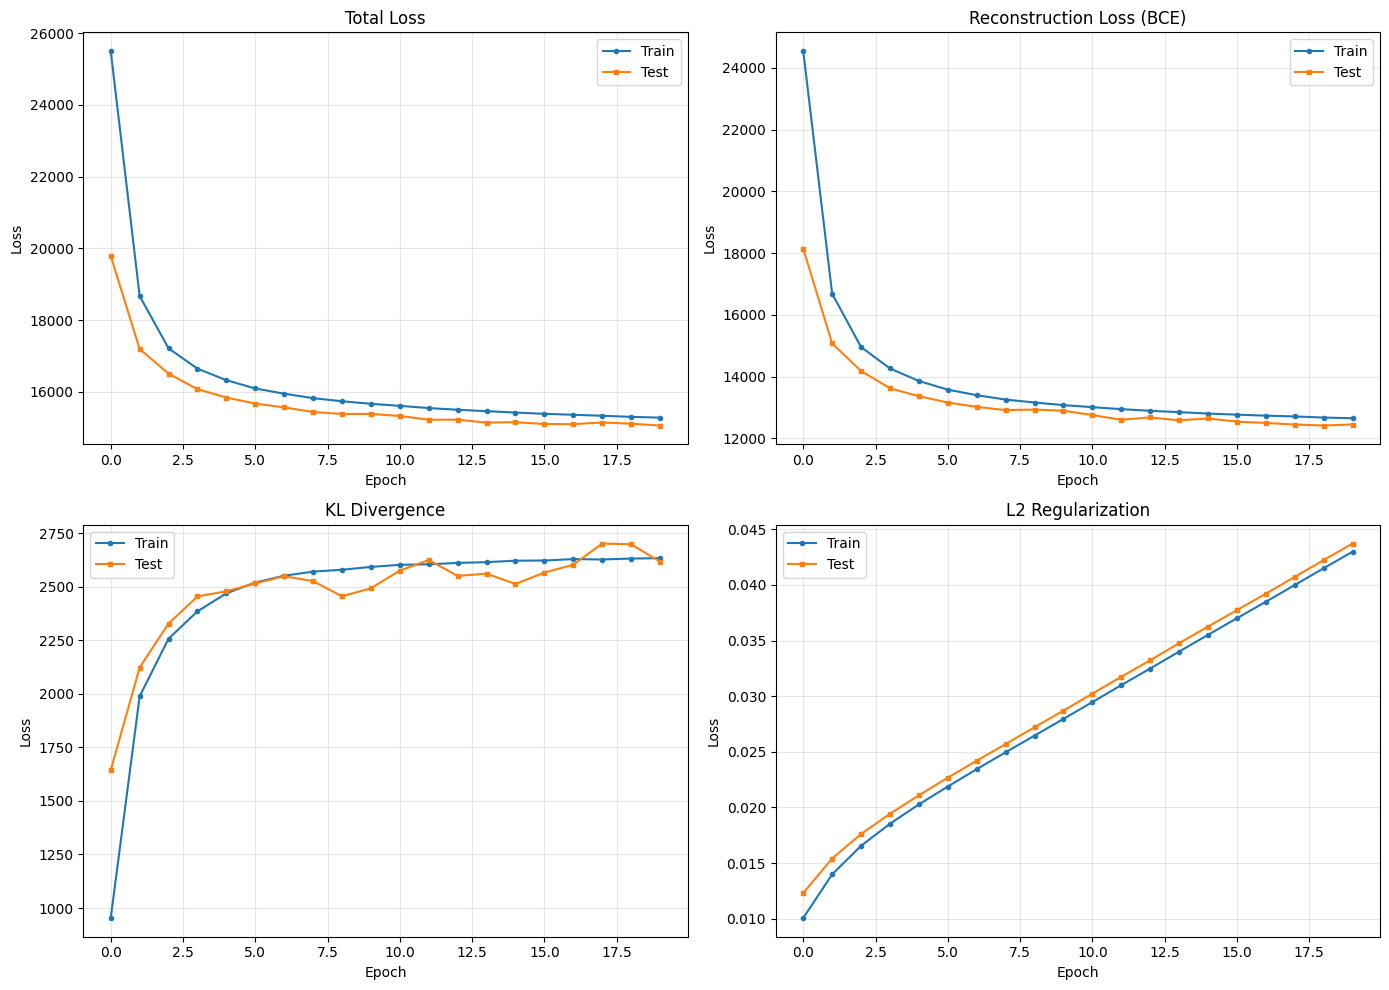

Saved training history plot


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total loss
axes[0, 0].plot(history['train_loss'], label='Train', marker='o', markersize=3)
axes[0, 0].plot(history['test_loss'], label='Test', marker='s', markersize=3)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Total Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# BCE loss
axes[0, 1].plot(history['train_bce'], label='Train', marker='o', markersize=3)
axes[0, 1].plot(history['test_bce'], label='Test', marker='s', markersize=3)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Reconstruction Loss (BCE)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# KLD loss
axes[1, 0].plot(history['train_kld'], label='Train', marker='o', markersize=3)
axes[1, 0].plot(history['test_kld'], label='Test', marker='s', markersize=3)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('KL Divergence')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# L2 Regularization loss
axes[1, 1].plot(history['train_l2'], label='Train', marker='o', markersize=3)
axes[1, 1].plot(history['test_l2'], label='Test', marker='s', markersize=3)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title('L2 Regularization')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved training history plot")

## 10. Plot Reconstructions

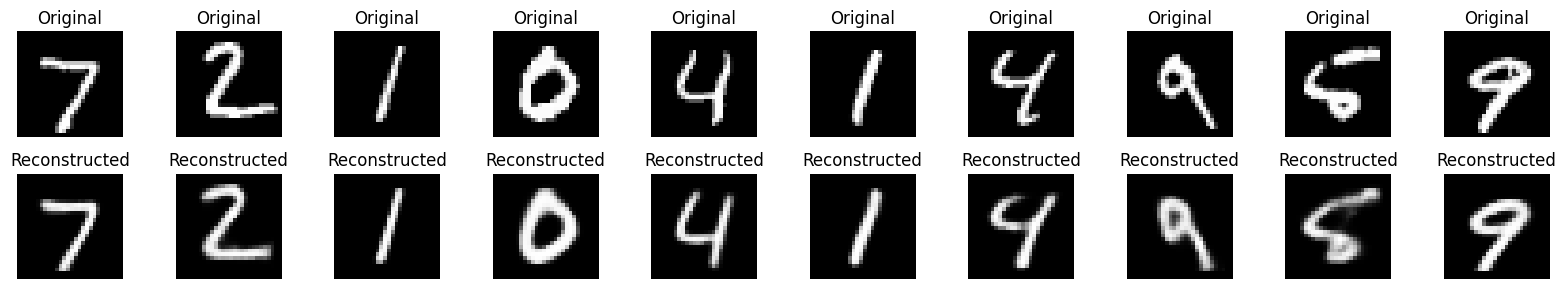

Saved reconstruction plot


In [19]:
model.eval()
n_samples = 10

with torch.no_grad():
    x, _ = next(iter(test_loader))
    x = x[:n_samples].to(device)
    recon_x, _, _, _ = model(x)

    x = x.cpu()
    recon_x = recon_x.cpu()

    fig, axes = plt.subplots(2, n_samples, figsize=(16, 3))
    for i in range(n_samples):
        axes[0, i].imshow(x[i, 0], cmap='gray')
        axes[0, i].set_title('Original')
        axes[0, i].axis('off')

        axes[1, i].imshow(recon_x[i, 0], cmap='gray')
        axes[1, i].set_title('Reconstructed')
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.savefig('reconstructions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved reconstruction plot")

## 11. Plot Latent Space

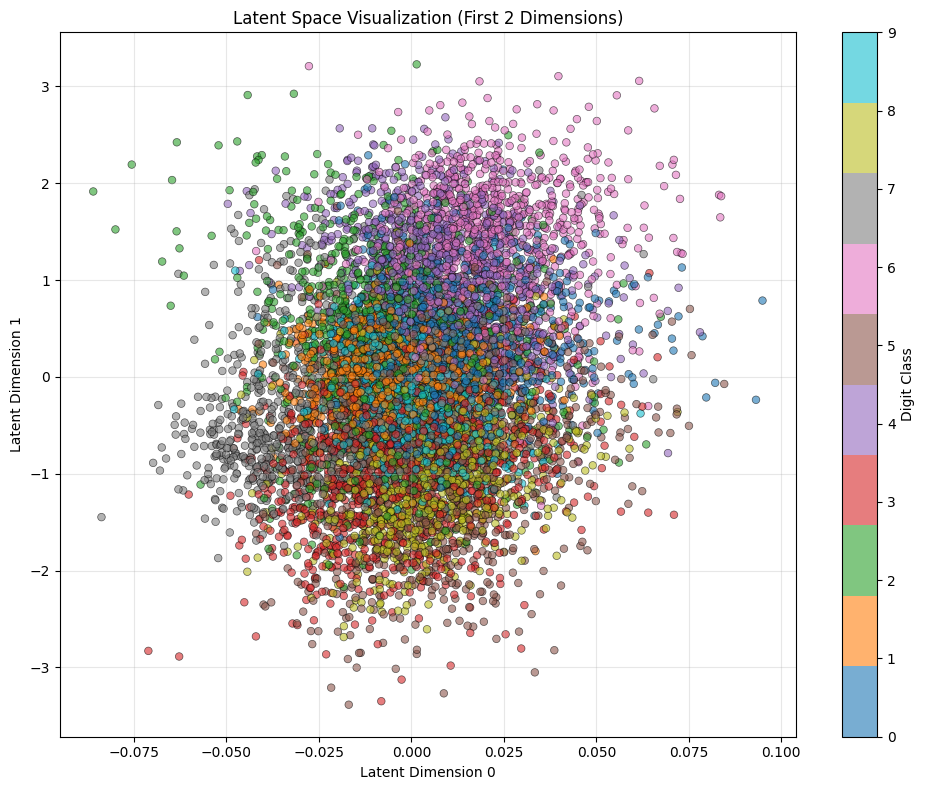

Saved latent space plot


In [20]:
model.eval()
latent_vectors = []
labels = []

with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Extracting latent vectors", leave=False):
        x = x.to(device)
        mu, _ = model.encoder(x)
        latent_vectors.append(mu.cpu())
        labels.append(y)

latent_vectors = torch.cat(latent_vectors)
labels = torch.cat(labels)

# Plot first 2 dimensions
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_vectors[:, 0], latent_vectors[:, 1],
                     c=labels, cmap='tab10', alpha=0.6, s=30, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Digit Class')
plt.xlabel('Latent Dimension 0')
plt.ylabel('Latent Dimension 1')
plt.title('Latent Space Visualization (First 2 Dimensions)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('latent_space.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved latent space plot")

## 12. Save Model

In [21]:
torch.save(model.state_dict(), 'vae_model.pth')
print("Model saved to vae_model.pth")

Model saved to vae_model.pth


## 13. Generate New Samples from Latent Space

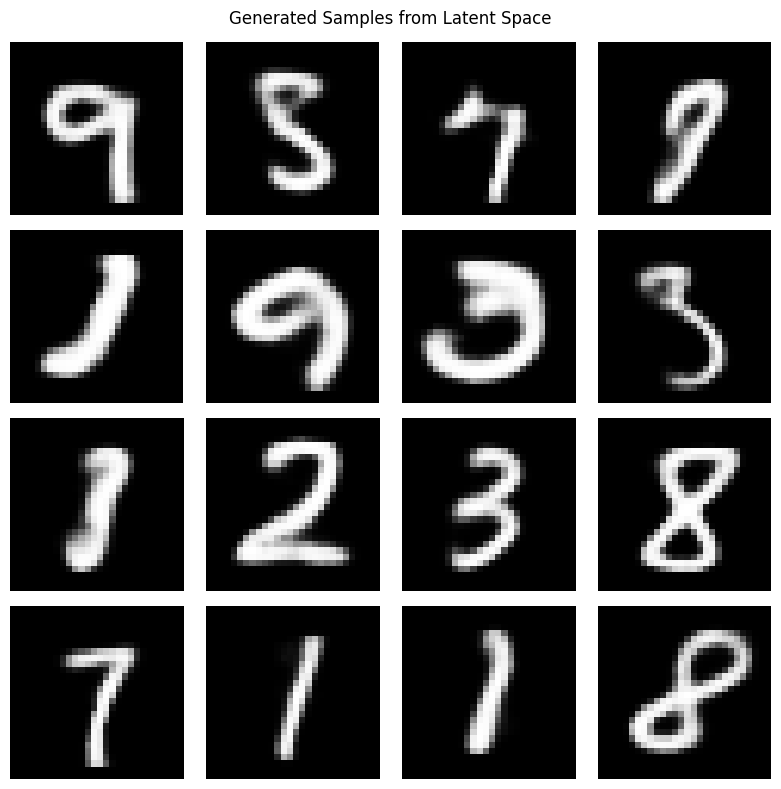

Saved generated samples plot


In [22]:
# Generate random samples from latent space
model.eval()
n_samples = 16

with torch.no_grad():
    # Sample from standard normal distribution
    z = torch.randn(n_samples, latent_dim).to(device)
    samples = model.decoder(z).cpu()

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i, 0], cmap='gray')
        ax.axis('off')

    plt.suptitle('Generated Samples from Latent Space')
    plt.tight_layout()
    plt.savefig('generated_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved generated samples plot")